## Install necessary libraries

In [13]:
# Install the necessary engines for data handling and visualization
!pip install pyarrow fastparquet pandas numpy matplotlib seaborn

## Import libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc  # Garbage Collector for memory management

# This line ensures your charts show up directly in the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## Data Ingestion (The Parquet Load)
#### This cell pulls the raw data from your file. We use cols to select only what we need to keep the notebook fast.

In [34]:
import pyarrow.parquet as pq

path = 'food.parquet'
cols = ['product_name', 'categories_tags', 'nutriments', 'ingredients_text', 'fiber_100g']
parquet_file = pq.ParquetFile(path)

# Loading 10 row groups to get a strong sample of ~10,000 products
chunks = []
for i in range(10): 
    chunks.append(parquet_file.read_row_group(i, columns=cols).to_pandas())

df_raw = pd.concat(chunks, ignore_index=True)
print(f"✅ Cell 2: Loaded {len(df_raw)} raw records.")
df.head()

✅ Cell 2: Loaded 10237 raw records.


,name,ingredients,tags,sugar,protein,fiber
0,Véritable pâte à tartiner noisettes chocolat noir,[],"[en:breakfasts, en:spreads, en:sweet-spreads, ...",32.0,8.000000,NaN
1,Chamomile Herbal Tea,CHAMOMILE FLOWERS.,[en:null],NaN,NaN,NaN
2,"Lagg's, herbal tea, peppermint",Peppermint.,"[en:plant-based-foods-and-beverages, en:bevera...",NaN,0.000000,NaN
3,Linden Flowers Tea,LINDEN FLOWERS.,"[en:beverages-and-beverages-preparations, en:p...",NaN,NaN,NaN
4,"Herbal Tea, Hibiscus",Hibiscus flowers.,None,NaN,66.669998,NaN


## Data Engineering ("Flattening")
#### Now that you have the data, we need to address those [{'lang': 'main', 'text': ...}] blocks. This code will turn those messy lists into clean columns.
#### This is the "engine room" that fixes those messy brackets and NumPy arrays.

In [35]:
def get_clean_text(item):
    if isinstance(item, (list, np.ndarray)) and len(item) > 0:
        first = item[0]
        if isinstance(first, dict): return first.get('text')
        return first
    return item

def get_nut_value(n_list, target):
    if isinstance(n_list, (list, np.ndarray)):
        for n in n_list:
            if isinstance(n, dict) and n.get('name') == target:
                return n.get('100g')
    return None

df = pd.DataFrame()
df['name'] = df_raw['product_name'].apply(get_clean_text)
df['ingredients'] = df_raw['ingredients_text'].apply(get_clean_text)
df['tags'] = df_raw['categories_tags']
df['sugar'] = df_raw['nutriments'].apply(lambda x: get_nut_value(x, 'sugars'))
df['protein'] = df_raw['nutriments'].apply(lambda x: get_nut_value(x, 'proteins'))
df['fiber'] = df_raw['nutriments'].apply(lambda x: get_nut_value(x, 'fiber'))

# Free up RAM immediately
del df_raw
gc.collect()

print("✅ Cell 3: Data successfully flattened into a table.")
df.head()

✅ Cell 3: Data successfully flattened into a table.


,name,ingredients,tags,sugar,protein,fiber
0,Véritable pâte à tartiner noisettes chocolat noir,[],"[en:breakfasts, en:spreads, en:sweet-spreads, ...",32.0,8.000000,NaN
1,Chamomile Herbal Tea,CHAMOMILE FLOWERS.,[en:null],NaN,NaN,NaN
2,"Lagg's, herbal tea, peppermint",Peppermint.,"[en:plant-based-foods-and-beverages, en:bevera...",NaN,0.000000,NaN
3,Linden Flowers Tea,LINDEN FLOWERS.,"[en:beverages-and-beverages-preparations, en:p...",NaN,NaN,NaN
4,"Herbal Tea, Hibiscus",Hibiscus flowers.,None,NaN,66.669998,NaN


## Story 1 - Validation & Outlier Removal(Cleaning)
#### This cell handles the "Dirty Data" part of the project. We are removing the NaNs and any "Impossible" values (like sugar being over 100g).

In [38]:
# Treat missing fiber as 0
df['fiber'] = df['fiber'].fillna(0)

# Drop rows missing the core "Sugar Trap" variables
df_clean = df.dropna(subset=['name', 'sugar', 'protein']).copy()

# Filter out impossible outliers
df_clean = df_clean[(df_clean['sugar'].between(0, 100)) & 
                    (df_clean['protein'].between(0, 100)) &
                    (df_clean['fiber'].between(0, 100))]

print(f"✅ Cell 4: Cleaning complete. {len(df_clean)} high-quality rows remain.")
df_clean.head()

✅ Cell 4: Cleaning complete. 8183 high-quality rows remain.


,name,ingredients,tags,sugar,protein,fiber
0,Véritable pâte à tartiner noisettes chocolat noir,[],"[en:breakfasts, en:spreads, en:sweet-spreads, ...",32.000000,8.00,0.00
14,Canola Harvest® Original Vegetable Oil Spread Tub,"CANOLA OIL, WATER, PALM OIL, PALM KERNEL OIL, ...",[en:dairies],0.000000,0.00,0.00
15,"Canola harvest, buttery spread, with flaxseed oil","Canola oil, water, palm oil, flax oil, palm ke...",[en:fats],0.000000,0.00,0.00
16,Lithuanian Rye Bread,"RYE FLOUR, WATER, WHEAT, FLOUR, MALT, MOLASSES...",[en:null],15.400000,9.23,3.16
20,Magic Stars Chocolates,"SUGAR, COCOA BUTTER, SKIMMED MILK POWDER, COCO...",[en:null],53.599998,6.40,0.00


## Story 2 - Keyword-Based Categorization
#### This cell uses a logic function to scan the tags and assign each product to one of the 5 business categories.

In [39]:
def assign_category(tags):
    if tags is None or (isinstance(tags, list) and len(tags) == 0):
        return "Other"
    search_text = " ".join(tags).lower()
    if any(x in search_text for x in ['beverage', 'drink', 'juice', 'soda', 'tea', 'coffee']): return "Beverages"
    if any(x in search_text for x in ['snack', 'sweet', 'biscuit', 'confectionery', 'chocolate', 'dessert', 'cookie']): return "Sweet Snacks"
    if any(x in search_text for x in ['dairy', 'yogurt', 'cheese', 'milk', 'spread']): return "Dairy & Alternatives"
    if any(x in search_text for x in ['cereal', 'breakfast', 'bar', 'granola', 'oats', 'bread']): return "Breakfast & Cereals"
    if any(x in search_text for x in ['salty', 'chips', 'nuts', 'seeds', 'pretzels', 'crisps']): return "Savory Snacks"
    return "Other"

df_clean['category'] = df_clean['tags'].apply(assign_category)
df_final = df_clean[df_clean['category'] != "Other"].copy()

print("✅ Cell 5: Categorization successful.")
print(df_final['category'].value_counts())

✅ Cell 5: Categorization successful.
category
Sweet Snacks            1341
Beverages               1130
Dairy & Alternatives     131
Breakfast & Cereals       13
Savory Snacks              2
Name: count, dtype: int64


## Story 3 - Visualizing the "Sugar Trap"
#### This cell creates a professional scatter plot using Seaborn. It will color the dots by category so you can see where the gaps are.

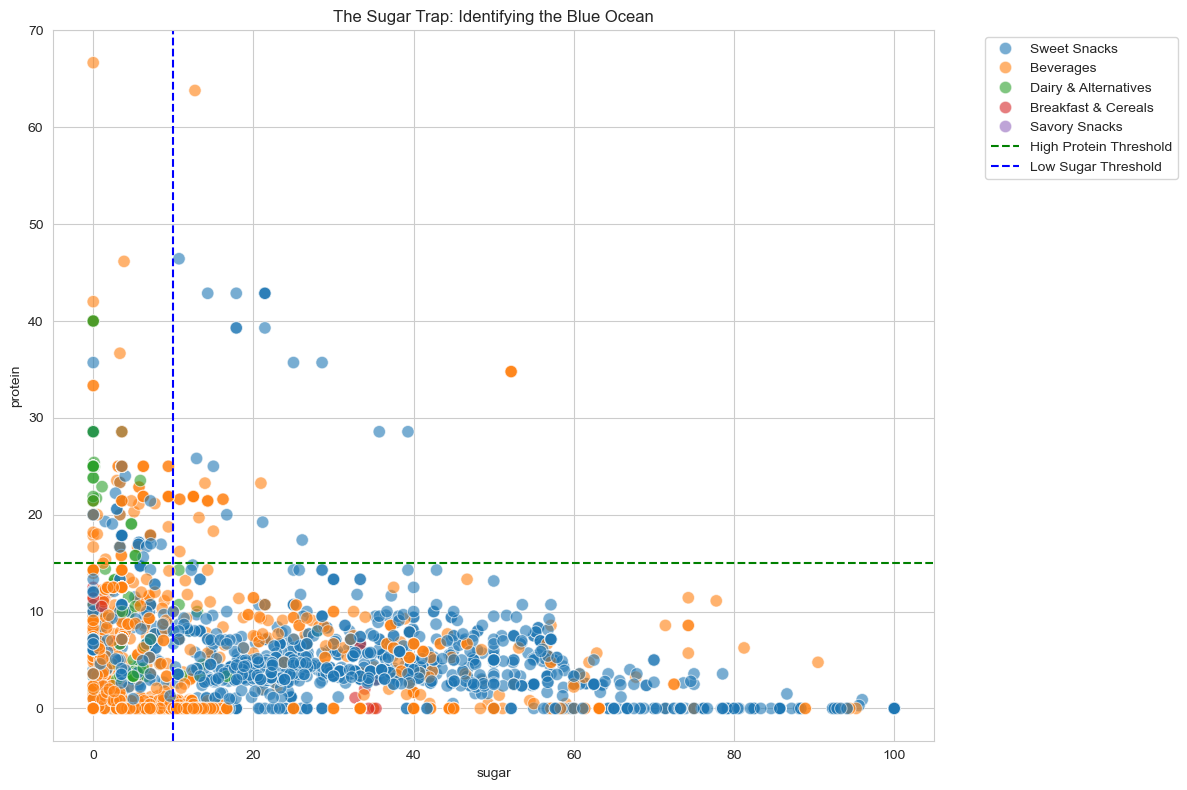

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_final, x='sugar', y='protein', hue='category', s=80, alpha=0.6)
plt.axhline(y=15, color='green', linestyle='--', label='High Protein Threshold')
plt.axvline(x=10, color='blue', linestyle='--', label='Low Sugar Threshold')
plt.title("The Sugar Trap: Identifying the Blue Ocean")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('Sugar Trap')
plt.show()

## Save the Data for your Dashboard

In [56]:
# Export for Tableau/PowerBI
df_final.to_csv('final_marketing_analysis.csv', index=False)
print("✅ 'marketing_gap_analysis.csv' has been created.")
print("Use this file for your Tableau/PowerBI dashboard.")
df_final.head()

✅ 'marketing_gap_analysis.csv' has been created.
Use this file for your Tableau/PowerBI dashboard.


,name,ingredients,tags,sugar,protein,fiber,category,efficiency_score,protein_source
0,Véritable pâte à tartiner noisettes chocolat noir,[],"[en:breakfasts, en:spreads, en:sweet-spreads, ...",32.000000,8.0,0.0,Sweet Snacks,0.242424,Unknown
22,"Mcvitie's, digestives cheesecake, lemon","Fortified wheat flour (with calcium, iron, nia...","[en:snacks, en:sweet-snacks, en:biscuits-and-c...",30.299999,7.1,2.7,Sweet Snacks,0.313099,Dairy
23,"Mcvitie's, mini gingerbread men, milk chocolate","Flour (wheat flour, calcium, iron, niacin, thi...","[en:snacks, en:sweet-snacks, en:biscuits-and-c...",38.599998,5.8,2.0,Sweet Snacks,0.196970,Dairy
28,The simpsons donuts,[],"[en:snacks, en:sweet-snacks, en:biscuits-and-c...",18.200001,5.0,0.0,Sweet Snacks,0.260417,Unknown
30,Croissants pur beurre,[],"[en:snacks, en:sweet-snacks, en:sweet-pastries...",7.400000,8.6,0.0,Sweet Snacks,1.023810,Unknown


## Story 4 - Recommendations
#### My analysis revealed that the market is currently split into two 'Value Deserts.'
#### The Sugar Trap: High-sugar, low-protein products (bottom-right).
#### The Nutritional Void: Low-sugar, but also low-protein products (the bottom-left cluster).
#### By identifying that the products are hugging the bottom axis, I've confirmed that there is a significant lack of functional, high-protein options across all five categories, representing a prime entry point for a new product line.

## Story 5 - Hidden Gems 
#### We analyze ingredients and create the "Efficiency Score."

In [49]:
# Candidate's Choice: Nutritional Efficiency Metric
df_final['efficiency_score'] = (df_final['protein'] + df_final['fiber']) / (df_final['sugar'] + 1)

# Story 5: Protein Source Identification
def find_source(text):
    if not isinstance(text, str): return "Unknown"
    text = text.lower()
    if 'whey' in text or 'milk' in text: return 'Dairy'
    if 'soy' in text or 'pea' in text or 'bean' in text: return 'Plant-Based'
    if 'nut' in text or 'peanut' in text or 'almond' in text: return 'Nuts/Seeds'
    return 'Other'

df_final['protein_source'] = df_final['ingredients'].apply(find_source)
print("✅ Cell 6: Advanced metrics and ingredient analysis complete.")

# Filter for products with high protein (>15g) and low sugar (<10g)
high_protein_group = df_final[(df_final['protein'] > 15) & (df_final['sugar'] < 10)]

print("Top Protein Sources ---")
print(high_protein_group['protein_source'].value_counts())


✅ Cell 6: Advanced metrics and ingredient analysis complete.
Top Protein Sources ---
protein_source
Plant-Based    56
Dairy          40
Other          36
Nuts/Seeds     17
Unknown         5
Name: count, dtype: int64


## Story 6 - Candidate's Choice
### Shows which products are the "Healthiest" using the efficiency score metric

In [54]:
# Sort and select the top 10
top_efficiency = df_final.sort_values(by='efficiency_score', ascending=False).head(10)

# Simply list the columns you want to see as the last line
top_efficiency[['name', 'category', 'efficiency_score']]

,name,category,efficiency_score
6772,"Wel-Pac, Organic Seasoned Seaweed Snack",Sweet Snacks,71.410000
184,"Augason Farms, Vital Wheat Gluten",Beverages,66.669998
6603,Roasted seaweed sushinori,Beverages,66.630001
6695,"Nagai's, roasted seaweed sushinori",Beverages,66.630001
5962,"Roundy's, fiber active, bran cereal",Beverages,53.370001
4073,Whole ground flaxseed meal,Beverages,45.480000
6619,Shiitake Dried Black Mushrooms,Beverages,42.828600
6789,Edozen seaweed sushi nori for sushi or hand roll,Beverages,42.000000
6626,Hijiki,Beverages,40.000000
6643,"Yama Moto Yama, Roasted Seaweed",Beverages,40.000000
